### Plotting Nearest-Neighbor Distance (NND) Metrics

- Load nearest-neighbour distance (NND) data
- Apply a consistent lek ordering and labels
- Plot NND metrics against the lek ID

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

In [2]:
## Output folder
out_dir = Path("output")
out_dir.mkdir(exist_ok=True)

In [3]:
## Save figure
def save_pub_fig(fig, filename_base, width=7, height=5, dpi=600):
    fig.set_size_inches(width, height)
    fig.savefig(f"{filename_base}.png", dpi=dpi, bbox_inches="tight")
    plt.close(fig)

In [15]:
## Load NND metrics
nnd_all = pd.read_csv('processed_data/nnd_ALL.csv')

## Factor ordering + labels
lek_order = ['Velavadar_LEK1', 'Velavadar_LEK2', 'TalChhapar_TC']
lek_labels = {'Velavadar_LEK1': 'Velavadar Lek 1','Velavadar_LEK2': 'Velavadar Lek 2','TalChhapar_TC': 'Tal Chhapar'}

nnd_all['lek_id'] = (pd.Categorical(nnd_all['lek_id'], categories=lek_order, ordered=True).rename_categories(lek_labels))

In [5]:
## Colour palettes (matched to R script)
fill_cols = {'Velavadar Lek 1': '#4DAF4A', 'Velavadar Lek 2': '#377EB8', 'Tal Chhapar': '#D6604D'}
point_cols = {'Velavadar Lek 1': '#1B7837', 'Velavadar Lek 2': '#2166AC', 'Tal Chhapar': '#8B1A1A'}

lek_labels = nnd_all['lek_id'].cat.categories.tolist()

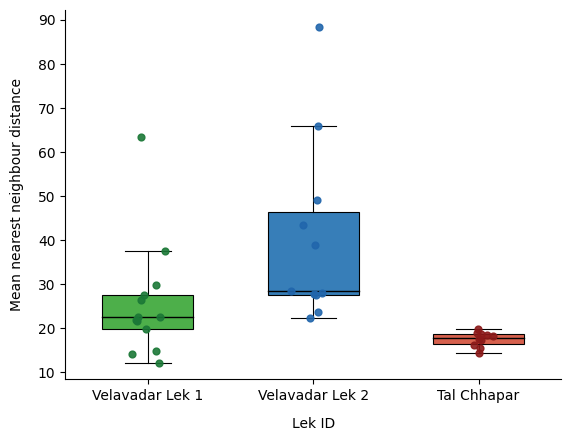

In [37]:
fig, ax = plt.subplots()

data_by_lek = [nnd_all.loc[nnd_all['lek_id'] == lek, 'nnd_mean'].values for lek in lek_labels]

bp = ax.boxplot(data_by_lek, positions=np.arange(len(lek_labels)), widths=0.55, patch_artist=True, 
                showfliers=False, boxprops=dict(linewidth=0.8, edgecolor='black'),
                medianprops=dict(color="black", linewidth=1.0), whiskerprops=dict(linewidth=0.8),
                capprops=dict(linewidth=0.8)
)

for patch, lek in zip(bp['boxes'], lek_labels):
    patch.set_facecolor(fill_cols[lek])

for i, lek in enumerate(lek_labels):
    y = nnd_all.loc[nnd_all['lek_id'] == lek, 'nnd_mean'].values
    x = np.random.normal(i, 0.06, size=len(y))
    ax.scatter(x, y, s=24, color=point_cols[lek], alpha=0.9, zorder=3)

ax.set_xticks(np.arange(len(lek_labels)))
ax.set_xticklabels(lek_labels)
ax.set_xlabel('Lek ID', labelpad=10)
ax.set_ylabel('Mean nearest neighbour distance', labelpad=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

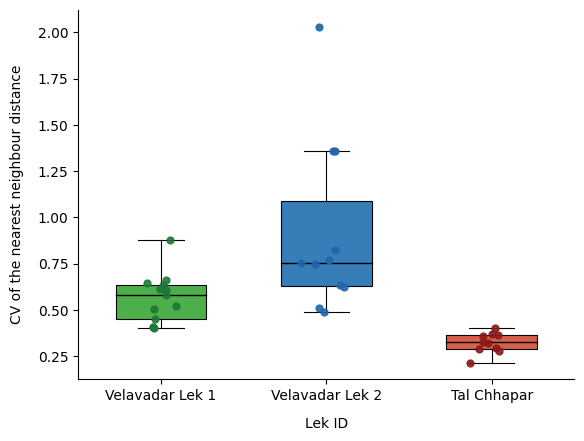

In [38]:
fig, ax = plt.subplots()

data_by_lek = [nnd_all.loc[nnd_all['lek_id'] == lek, 'nnd_cv'].values for lek in lek_labels]

bp = ax.boxplot(data_by_lek, positions=np.arange(len(lek_labels)), widths=0.55, patch_artist=True, 
                showfliers=False, boxprops=dict(linewidth=0.8, edgecolor='black'),
                medianprops=dict(color="black", linewidth=1.0), whiskerprops=dict(linewidth=0.8),
                capprops=dict(linewidth=0.8)
)

for patch, lek in zip(bp['boxes'], lek_labels):
    patch.set_facecolor(fill_cols[lek])

for i, lek in enumerate(lek_labels):
    y = nnd_all.loc[nnd_all['lek_id'] == lek, 'nnd_cv'].values
    x = np.random.normal(i, 0.06, size=len(y))
    ax.scatter(x, y, s=24, color=point_cols[lek], alpha=0.9, zorder=3)

ax.set_xticks(np.arange(len(lek_labels)))
ax.set_xticklabels(lek_labels)
ax.set_xlabel('Lek ID', labelpad=10)
ax.set_ylabel('CV of the nearest neighbour distance', labelpad=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

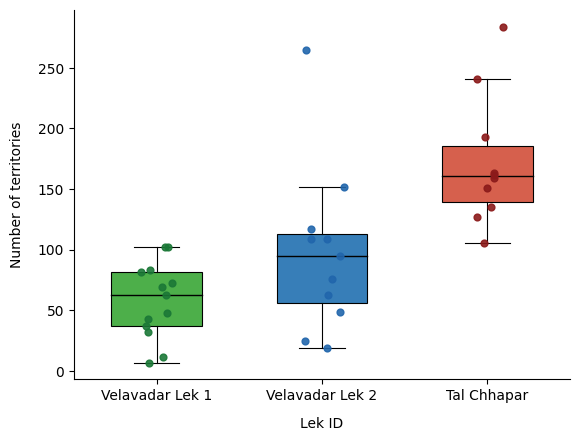

In [34]:
fig, ax = plt.subplots()

data_by_lek = [nnd_all.loc[nnd_all['lek_id'] == lek, 'nnd_count'].values for lek in lek_labels]

bp = ax.boxplot(data_by_lek, positions=np.arange(len(lek_labels)), widths=0.55, patch_artist=True, 
                showfliers=False, boxprops=dict(linewidth=0.8, edgecolor='black'),
                medianprops=dict(color="black", linewidth=1.0), whiskerprops=dict(linewidth=0.8),
                capprops=dict(linewidth=0.8)
)

for patch, lek in zip(bp['boxes'], lek_labels):
    patch.set_facecolor(fill_cols[lek])

for i, lek in enumerate(lek_labels):
    y = nnd_all.loc[nnd_all['lek_id'] == lek, 'nnd_count'].values
    x = np.random.normal(i, 0.06, size=len(y))
    ax.scatter(x, y, s=24, color=point_cols[lek], alpha=0.9, zorder=3)

ax.set_xticks(np.arange(len(lek_labels)))
ax.set_xticklabels(lek_labels)
ax.set_xlabel('Lek ID', labelpad=10)
ax.set_ylabel('Number of territories', labelpad=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)